**Objective:**

We are dealing with multiple `stationID` values occurring at the same `connectionTime` and checking outliers in the `KWhDelivered`, `total_charging_time`, and `idle_time` variables in this notebook. Also we are applying smoothing technique (Croston TSB) for handling Intermittent demand

**Input**: `acn_office_0.2_0.1_with_stationID_22_06_2023.csv`

**Output**: `acn_office_0.2_0.1_22_06_2023.csv`

**Reference**:`20/03/2023 office1 w/o stationID part-2.ipynb`

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
os.chdir("/content/drive/My Drive/TL_A/DeepKale/experiments_0.2/notebook/data_processing/transfer_model/")
!ls

19062023_office_data_preprocessing_without_stationID_part_2.ipynb
19062023_office_data_preprocessing_with_stationID_part_1.ipynb


In [3]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline, interp1d
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.express as px

SEED = 42
np.random.seed(SEED)

In [4]:
df_office = pd.read_csv('../../../data/preprocessed/ACN/acn_office_0.2_0.1_with_stationID_22_06_2023.csv')

In [5]:
df_office.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   connectionTime       1032 non-null   object 
 1   kWhDelivered         1032 non-null   float64
 2   siteID               1032 non-null   int64  
 3   stationID            1032 non-null   int64  
 4   total_charging_time  1032 non-null   float64
 5   idle_time            1032 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 48.5+ KB


In [6]:
# Total unique stationID of df_office
print("Total unique stationID in df_office:", df_office['stationID'].nunique())

Total unique stationID in df_office: 8


In [7]:
# Total unique stationID of df_office
print("Total unique stationID in df_office:", df_office['siteID'].nunique())

df_office['siteID'].unique()

Total unique stationID in df_office: 1


array([19])

In [8]:
final_df = df_office.copy()

In [9]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   connectionTime       1032 non-null   object 
 1   kWhDelivered         1032 non-null   float64
 2   siteID               1032 non-null   int64  
 3   stationID            1032 non-null   int64  
 4   total_charging_time  1032 non-null   float64
 5   idle_time            1032 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 48.5+ KB


In [10]:
final_df = final_df.sort_values('connectionTime').reset_index(drop=True)

In [11]:
final_df.describe()

,kWhDelivered,siteID,stationID,total_charging_time,idle_time
count,1032.000000,1032.0,1032.000000,1032.000000,1032.000000
mean,14.059931,19.0,1636.232558,3.283876,2.177653
std,9.631717,0.0,2.520947,2.090023,2.586597
min,0.520000,19.0,1633.000000,0.190278,0.000833
25%,5.882250,19.0,1634.000000,1.707222,0.002500
50%,11.720000,19.0,1636.000000,2.657083,1.033056
75%,22.059250,19.0,1639.000000,4.758819,3.720833
max,38.382000,19.0,1640.000000,8.465833,10.235000


In [12]:
final_df['connectionTime'] = pd.to_datetime(final_df['connectionTime'])

In [13]:
final_df.head(15)

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
0,2019-03-25 09:24:42,6.146,19,1633,1.135000,7.990000
1,2019-03-25 10:19:27,3.658,19,1634,0.689444,6.633611
2,2019-03-25 14:27:32,28.330,19,1640,4.718889,1.356389
3,2019-03-26 11:33:56,12.978,19,1640,3.950556,2.243056
4,2019-03-27 11:28:01,10.688,19,1640,3.267222,2.895556
5,2019-03-27 17:32:33,17.591,19,1635,2.846944,0.047222
6,2019-03-29 09:30:38,22.407,19,1634,3.541111,0.001111
7,2019-03-29 11:26:24,15.762,19,1636,4.689444,1.008333
8,2019-03-29 13:21:24,21.026,19,1640,3.406389,3.445000
9,2019-03-29 13:49:21,7.328,19,1634,1.181944,2.935000


In [14]:
final_df.shape

(1032, 6)

In [15]:
final_df_before_COVID = final_df.loc[final_df['connectionTime'] < pd.to_datetime('2020-03-15')]
final_df_before_COVID.shape

(1032, 6)

In [16]:
final_df_before_COVID.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1032 entries, 0 to 1031
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       1032 non-null   datetime64[ns]
 1   kWhDelivered         1032 non-null   float64       
 2   siteID               1032 non-null   int64         
 3   stationID            1032 non-null   int64         
 4   total_charging_time  1032 non-null   float64       
 5   idle_time            1032 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 56.4 KB


In [17]:
df_H = final_df_before_COVID.copy()

# Convert the 'connectionTime' column to datetime and set it as the index
df_H.set_index('connectionTime', inplace=True)

# Resample the DataFrame to hourly frequency and count the number of missing values
df_H = df_H.resample('H').mean()  # use 'mean' or another method to aggregate the 'kWhDelivered' values
num_missing = df_H['kWhDelivered'].isna().sum()

# Calculate the percentage of available and missing data
total_hours = len(df_H)
pct_available = (total_hours - num_missing) / total_hours * 100
pct_missing = num_missing / total_hours * 100

print(f'Percentage of available data: {pct_available:.2f}%')
print(f'Percentage of missing data: {pct_missing:.2f}%')

Percentage of available data: 9.92%
Percentage of missing data: 90.08%


In [18]:
# Group by hourly timestamps and concatenate station IDs and site IDs with underscores
final_df_before_COVID_hourly = final_df_before_COVID.groupby(pd.Grouper(key='connectionTime', freq='1H')) \
    .agg({'stationID': lambda x: '_'.join(x.unique().astype(str)),
          'siteID': lambda x: '_'.join(x.unique().astype(str))}) \
    .reset_index()


# Take the mean of the other columns within each hourly group
hourly_mean = final_df_before_COVID.groupby(pd.Grouper(key='connectionTime', freq='1H')) \
    .mean() \
    .reset_index()

# Merge the two dataframes
final_df_before_COVID_hourly = pd.merge(final_df_before_COVID_hourly, hourly_mean, on='connectionTime')

# Fill missing values with 0
final_df_before_COVID_hourly.fillna(value=0, inplace=True)

# Rename columns
final_df_before_COVID_hourly.rename(columns={'stationID_x': 'stationID', 'siteID_x': 'siteID'}, inplace=True)

# Drop redundant columns
final_df_before_COVID_hourly.drop(columns=['stationID_y', 'siteID_y'], inplace=True)

final_df_before_COVID_hourly['stationID'] = final_df_before_COVID_hourly['stationID'].replace('', 0)
final_df_before_COVID_hourly['siteID'] = final_df_before_COVID_hourly['siteID'].replace('', 0)

In [19]:
unique_siteIDs = final_df_before_COVID_hourly['siteID'].unique()
print("Unique siteIDs:", unique_siteIDs)
print("Number of unique siteIDs:", len(unique_siteIDs))

Unique siteIDs: ['19' 0]
Number of unique siteIDs: 2


In [20]:
final_df_before_COVID_hourly.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8500 entries, 0 to 8499
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       8500 non-null   datetime64[ns]
 1   stationID            8500 non-null   object        
 2   siteID               8500 non-null   object        
 3   kWhDelivered         8500 non-null   float64       
 4   total_charging_time  8500 non-null   float64       
 5   idle_time            8500 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 464.8+ KB


In [21]:
final_df_before_COVID_hourly

,connectionTime,stationID,siteID,kWhDelivered,total_charging_time,idle_time
0,2019-03-25 09:00:00,1633,19,6.146,1.135000,7.990000
1,2019-03-25 10:00:00,1634,19,3.658,0.689444,6.633611
2,2019-03-25 11:00:00,0,0,0.000,0.000000,0.000000
3,2019-03-25 12:00:00,0,0,0.000,0.000000,0.000000
4,2019-03-25 13:00:00,0,0,0.000,0.000000,0.000000
...,...,...,...,...,...,...
8495,2020-03-13 08:00:00,0,0,0.000,0.000000,0.000000
8496,2020-03-13 09:00:00,0,0,0.000,0.000000,0.000000
8497,2020-03-13 10:00:00,0,0,0.000,0.000000,0.000000
8498,2020-03-13 11:00:00,1639_1640,19,17.723,3.430278,2.711667


In [22]:
final_df_before_COVID_hourly.drop(columns=['stationID'], inplace=True)
final_df_before_COVID_hourly['siteID'] = final_df_before_COVID_hourly['siteID'].fillna(0)

In [23]:
unique_siteIDs = final_df_before_COVID_hourly['siteID'].unique()
print("Unique siteIDs:", unique_siteIDs)
print("Number of unique siteIDs:", len(unique_siteIDs))

Unique siteIDs: ['19' 0]
Number of unique siteIDs: 2


In [24]:
print(final_df_before_COVID_hourly.isnull().sum())

connectionTime         0
siteID                 0
kWhDelivered           0
total_charging_time    0
idle_time              0
dtype: int64


In [25]:
final_df_before_COVID_hourly

,connectionTime,siteID,kWhDelivered,total_charging_time,idle_time
0,2019-03-25 09:00:00,19,6.146,1.135000,7.990000
1,2019-03-25 10:00:00,19,3.658,0.689444,6.633611
2,2019-03-25 11:00:00,0,0.000,0.000000,0.000000
3,2019-03-25 12:00:00,0,0.000,0.000000,0.000000
4,2019-03-25 13:00:00,0,0.000,0.000000,0.000000
...,...,...,...,...,...
8495,2020-03-13 08:00:00,0,0.000,0.000000,0.000000
8496,2020-03-13 09:00:00,0,0.000,0.000000,0.000000
8497,2020-03-13 10:00:00,0,0.000,0.000000,0.000000
8498,2020-03-13 11:00:00,19,17.723,3.430278,2.711667


**Croston TSB Smoothing**

In [26]:
def Croston_TSB_smooth(ts, extra_periods=1, alpha=0.4, beta=0.4, epsilon=1e-8):
    d = np.array(ts) # Transform the input into a numpy array
    cols = len(d) # Historical period length
    d = np.append(d,[np.nan]*extra_periods) # Append np.nan into the demand array to cover future periods

    # Level (a) and probability(p)
    a, p = np.full((2, cols + extra_periods), np.nan)

    # Initialization
    first_occurence = np.argmax(d[:cols] > 0)
    a[0] = d[first_occurence]
    p[0] = 1 / (1 + first_occurence)

    # Create all the t+1 forecasts
    for t in range(0, cols):
        if d[t] > 0:
            a[t+1] = alpha * d[t] + (1 - alpha) * a[t]
            p[t+1] = beta * (1) + (1 - beta) * p[t]
        else:
            a[t+1] = a[t]
            p[t+1] = (1 - beta) * p[t]

    # Future Forecast
    a[cols+1:cols+extra_periods] = a[cols]
    p[cols+1:cols+extra_periods] = p[cols]

    # Calculate the smoothed values
    denominator = 1 - (1 - alpha) * p[:-1]
    denominator[denominator < epsilon] = epsilon  # Replace values close to zero with epsilon
    smoothed = a[:-1] * p[:-1] / denominator

    return smoothed

In [27]:
# Generate the smoothed data for a range of alpha and beta values
alpha_range = np.linspace(0, 1, 11)
beta_range = np.linspace(0, 1, 11)

mse_list = []
for alpha in alpha_range:
    for beta in beta_range:
        smoothed_data = Croston_TSB_smooth(final_df_before_COVID_hourly['kWhDelivered'], alpha=alpha, beta=beta)
        mse = np.mean((final_df_before_COVID_hourly['kWhDelivered'] - smoothed_data) ** 2)
        mse_list.append([alpha, beta, mse])

# Convert the list of results to a pandas DataFrame
mse_df = pd.DataFrame(mse_list, columns=['alpha', 'beta', 'mse'])

# Find the alpha and beta values with the lowest mse
best_params = mse_df.loc[mse_df['mse'].idxmin()]

# Generate the smoothed data with the best alpha and beta values
smoothed_data = Croston_TSB_smooth(final_df_before_COVID_hourly['kWhDelivered'], alpha=best_params['alpha'], beta=best_params['beta'])

# Plot the original and smoothed data using Plotly Express

fig = px.line(final_df_before_COVID_hourly, x='connectionTime', y='kWhDelivered', title='Hourly kWh Delivered')
fig.add_scatter(x=final_df_before_COVID_hourly['connectionTime'], y=smoothed_data, mode='lines', name='Croston Smoothing')
fig.show()
print(best_params)

In [28]:
final_df_before_COVID_hourly['kWhDelivered_Smoothed'] = smoothed_data

alpha     0.700000
beta      0.100000
mse      26.513579
Name: 78, dtype: float64


In [29]:
# Convert total_charging_time and idle_time columns to numeric data types
final_df_before_COVID_hourly['total_charging_time'] = pd.to_numeric(final_df_before_COVID_hourly['total_charging_time'], errors='coerce')
final_df_before_COVID_hourly['idle_time'] = pd.to_numeric(final_df_before_COVID_hourly['idle_time'], errors='coerce')
# Generate smoothed data for total_charging_time column
mse_list = []
for alpha in alpha_range:
    for beta in beta_range:
        smoothed_data = Croston_TSB_smooth(final_df_before_COVID_hourly['total_charging_time'], alpha=alpha, beta=beta)
        mse = np.mean((final_df_before_COVID_hourly['total_charging_time'] - smoothed_data) ** 2)
        mse_list.append([alpha, beta, mse])

mse_df = pd.DataFrame(mse_list, columns=['alpha', 'beta', 'mse'])
best_params = mse_df.loc[mse_df['mse'].idxmin()]
final_df_before_COVID_hourly['total_charging_time_Smoothed'] = Croston_TSB_smooth(final_df_before_COVID_hourly['total_charging_time'], alpha=best_params['alpha'], beta=best_params['beta'])
print(best_params)

alpha    0.300000
beta     0.100000
mse      1.430716
Name: 34, dtype: float64


In [30]:
# Plot the original and smoothed data for total_charging_time and idle_time columns
fig1 = px.line(final_df_before_COVID_hourly, x='connectionTime', y='total_charging_time', title='Hourly Total Charging Time')
fig1.add_scatter(x=final_df_before_COVID_hourly['connectionTime'], y=final_df_before_COVID_hourly['total_charging_time_Smoothed'], mode='lines', name='Croston Smoothing')
fig1.show()

In [31]:
# Generate smoothed data for idle_time column
mse_list = []
for alpha in alpha_range:
    for beta in beta_range:
        smoothed_data = Croston_TSB_smooth(final_df_before_COVID_hourly['idle_time'], alpha=alpha, beta=beta)
        mse = np.mean((final_df_before_COVID_hourly['idle_time'] - smoothed_data) ** 2)
        mse_list.append([alpha, beta, mse])

mse_df = pd.DataFrame(mse_list, columns=['alpha', 'beta', 'mse'])
best_params = mse_df.loc[mse_df['mse'].idxmin()]
final_df_before_COVID_hourly['idle_time_Smoothed'] = Croston_TSB_smooth(final_df_before_COVID_hourly['idle_time'], alpha=best_params['alpha'], beta=best_params['beta'])
print(best_params)

alpha    0.900000
beta     0.100000
mse      1.040127
Name: 100, dtype: float64


In [32]:
fig2 = px.line(final_df_before_COVID_hourly, x='connectionTime', y='idle_time', title='Hourly Idle Time')
fig2.add_scatter(x=final_df_before_COVID_hourly['connectionTime'], y=final_df_before_COVID_hourly['idle_time_Smoothed'], mode='lines', name='Croston Smoothing')
fig2.show()

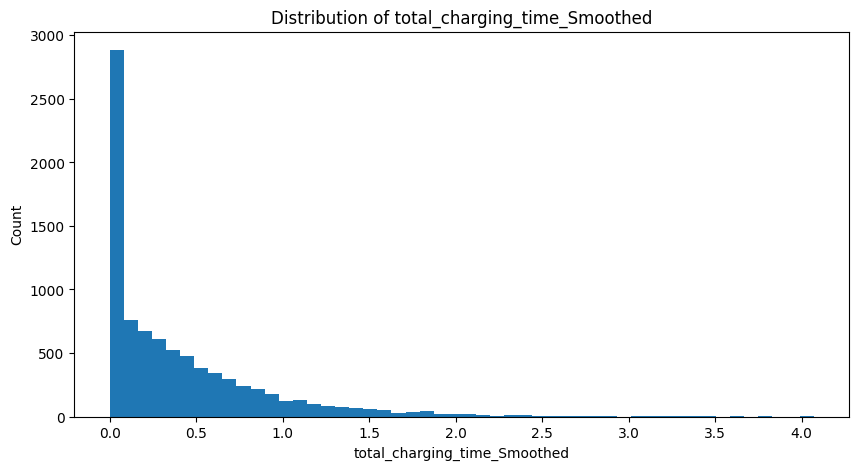

In [33]:
plt.figure(figsize=(10, 5))
plt.hist(final_df_before_COVID_hourly['total_charging_time_Smoothed'], bins=50)
plt.xlabel('total_charging_time_Smoothed')
plt.ylabel('Count')
plt.title('Distribution of total_charging_time_Smoothed')
plt.show()

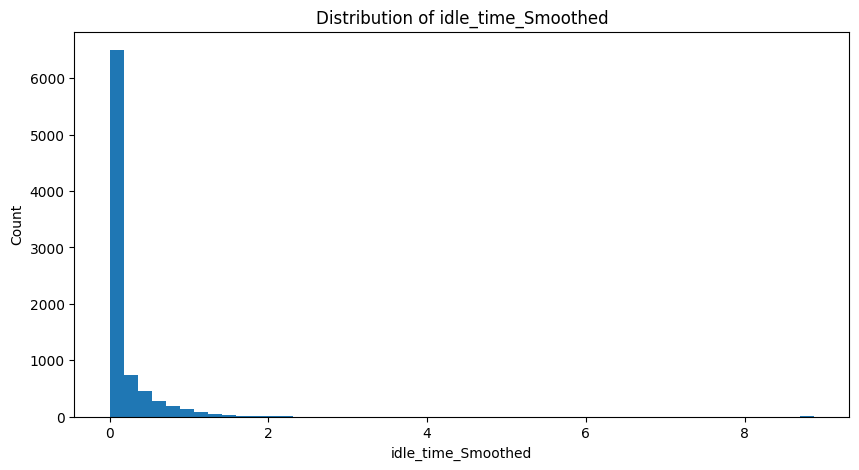

In [34]:
plt.figure(figsize=(10, 5))
plt.hist(final_df_before_COVID_hourly['idle_time_Smoothed'], bins=50)
plt.xlabel('idle_time_Smoothed')
plt.ylabel('Count')
plt.title('Distribution of idle_time_Smoothed')
plt.show()

In [35]:
final_df_before_COVID_hourly.columns.tolist()

['connectionTime',
 'siteID',
 'kWhDelivered',
 'total_charging_time',
 'idle_time',
 'kWhDelivered_Smoothed',
 'total_charging_time_Smoothed',
 'idle_time_Smoothed']

In [36]:
final_df_before_COVID_hourly

,connectionTime,siteID,kWhDelivered,total_charging_time,idle_time,kWhDelivered_Smoothed,total_charging_time_Smoothed,idle_time_Smoothed
0,2019-03-25 09:00:00,19,6.146,1.135000,7.990000,8.780000,3.783333,8.877778
1,2019-03-25 10:00:00,19,3.658,0.689444,6.633611,8.780000,3.783333,8.877778
2,2019-03-25 11:00:00,0,0.000,0.000000,0.000000,6.292000,3.337778,7.521389
3,2019-03-25 12:00:00,0,0.000,0.000000,0.000000,5.430082,2.435676,6.694863
4,2019-03-25 13:00:00,0,0.000,0.000000,0.000000,4.712766,1.873164,5.966368
...,...,...,...,...,...,...,...,...
8495,2020-03-13 08:00:00,0,0.000,0.000000,0.000000,2.080977,0.738935,0.811448
8496,2020-03-13 09:00:00,0,0.000,0.000000,0.000000,1.859390,0.652807,0.728622
8497,2020-03-13 10:00:00,0,0.000,0.000000,0.000000,1.662673,0.577958,0.654404
8498,2020-03-13 11:00:00,19,17.723,3.430278,2.711667,1.487782,0.512647,0.587870


In [37]:
final_df_before_COVID_hourly.describe()

,kWhDelivered,total_charging_time,idle_time,kWhDelivered_Smoothed,total_charging_time_Smoothed,idle_time_Smoothed
count,8500.000000,8500.000000,8500.000000,8.500000e+03,8.500000e+03,8.500000e+03
mean,1.399340,0.328437,0.213377,1.420020e+00,3.942337e-01,1.582751e-01
std,5.079662,1.170171,0.996629,1.783597e+00,4.756966e-01,3.435696e-01
min,0.000000,0.000000,0.000000,1.523264e-21,4.470595e-22,1.807776e-22
25%,0.000000,0.000000,0.000000,9.457178e-02,2.644043e-02,1.263190e-03
50%,0.000000,0.000000,0.000000,8.226674e-01,2.358192e-01,2.144706e-02
75%,0.000000,0.000000,0.000000,2.028119e+00,5.858428e-01,1.596629e-01
max,38.382000,8.465833,10.235000,2.068532e+01,4.072845e+00,8.877778e+00


In [38]:
file_path = '../../../data/preprocessed/ACN/acn_office_0.2_0.1_22_06_2023.csv'
final_df_before_COVID_hourly.to_csv(file_path, index=False)